# Imports

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import qiskit
import numpy as np
from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram
from qiskit.circuit import Parameter
import random

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from qiskit.circuit import Parameter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading data


In [2]:
iris = load_iris()
X, y = iris.data, iris.target

## Data exploration

In [3]:
# Data exploration
print(f"Number of data points (rows): {X.shape[0]}")
print(f"Number of input dimensions (features): {X.shape[1]}")
print(f"Number of targets: {len(y)}")
print(f"Range of feature values: min {np.min(X)} - max {np.max(X)}")
print(f"Unique target values: {np.unique(y)}")

Number of data points (rows): 150
Number of input dimensions (features): 4
Number of targets: 150
Range of feature values: min 0.1 - max 7.9
Unique target values: [0 1 2]


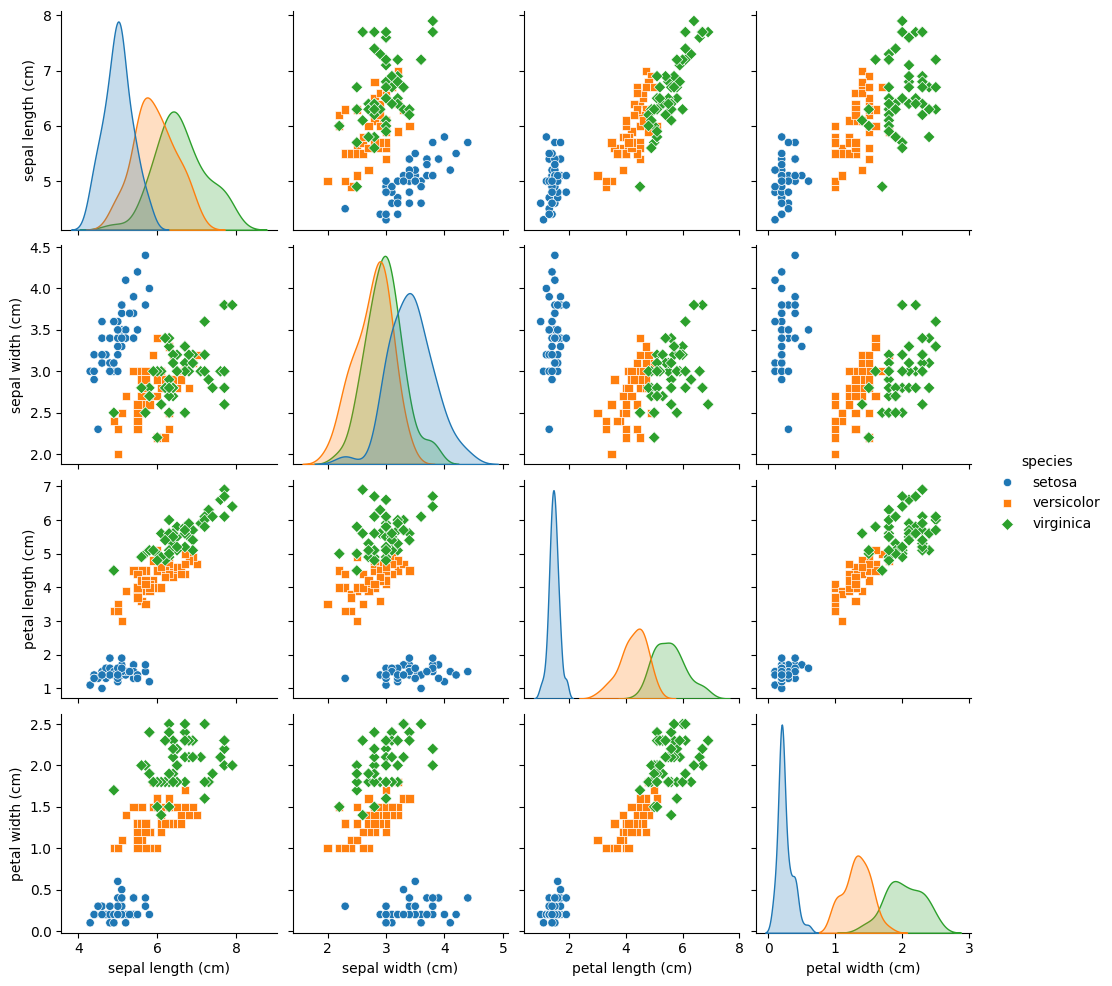

Feature Value Statistics (Min, Max, Range):
sepal length (cm):
  Min: 4.30
  Max: 7.90
  Range: 3.60

sepal width (cm):
  Min: 2.00
  Max: 4.40
  Range: 2.40

petal length (cm):
  Min: 1.00
  Max: 6.90
  Range: 5.90

petal width (cm):
  Min: 0.10
  Max: 2.50
  Range: 2.40



In [4]:
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].apply(lambda x: iris.target_names[x])

# Plot pairplot to visualize feature distributions
sns.pairplot(iris_df, hue='species', markers=["o", "s", "D"])
plt.show()

features = iris_df.columns[:-1]  # Select all feature columns except the 'species'

print("Feature Value Statistics (Min, Max, Range):")
for feature in features:
    feature_min = iris_df[feature].min()
    feature_max = iris_df[feature].max()
    feature_range = feature_max - feature_min
    print(f"{feature}:")
    print(f"  Min: {feature_min:.2f}")
    print(f"  Max: {feature_max:.2f}")
    print(f"  Range: {feature_range:.2f}\n")

## Normalizing and scaling data

In [5]:
# Normalize each column independently to the range 0 to π
min_vals = np.min(X, axis=0)  # Min values for each column
max_vals = np.max(X, axis=0)  # Max values for each column

normalized_X = (X - min_vals) / (max_vals - min_vals) * np.pi

in_min, in_max = normalized_X.min(),normalized_X.max()

print(f"Input range: ({in_min}-{in_max})")

Input range: (0.0-3.141592653589793)


## Splitting data

In [6]:
random_seed = 69 #Seed for reproduceability
np.random.seed(random_seed)
X_train, X_val_test, y_train, y_val_test = train_test_split(normalized_X, y, test_size=0.40, random_state=random_seed)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.50, random_state=random_seed)

## Building circuits

C:\Users\halfd\inf2\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


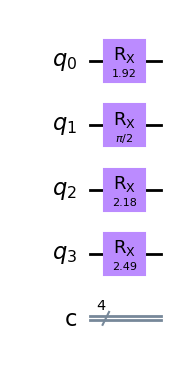

In [7]:
#The encoding circuit should encode the data, but should be able to connect to bigger circuits
def create_encoding_circuit(features, n_qubits=4):
    n_features = len(features)
    qc = QuantumCircuit(n_qubits, n_features)
    for i in range(n_features):
        qc.rx(features[i],i)
    return qc

encode_circuit = create_encoding_circuit(X_train[0], n_qubits=4)

encode_circuit.draw("mpl")

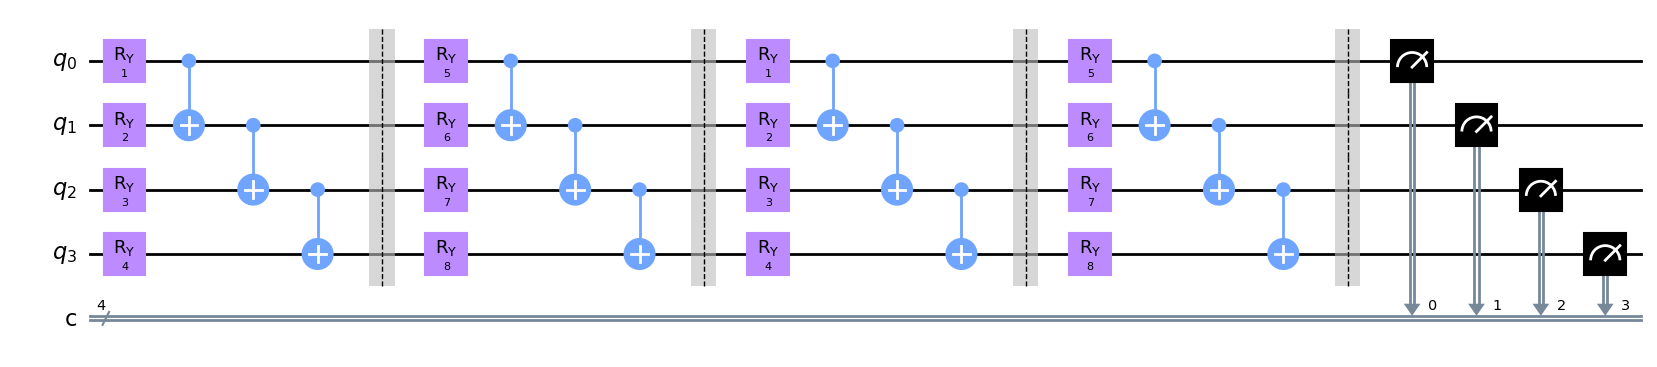

In [8]:
#Simplest NN, but with ability to change the number of layers
class QuantumNN:
    def __init__(self, n_layers, n_qubits):
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.params = [Parameter(f"θ_{i}_{j}") for i in range(n_layers) for j in range(n_qubits)]
        self.qc = self.create_simple_variational_circuit(n_layers, n_qubits)
        self.values = [np.random.uniform(0, np.pi) for _ in self.params]

    
    def get_parameters(self):
        return self.param_values

    def get_values(self):
        return self.values

    def update_values(self, values):
        self.values = values
    
    def get_qc(self, values=None):
        if values is None:  # Use 'is None' for checking against None
            param_values = {param: value for param, value in zip(self.params, self.values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        else:
            param_values = {param: value for param, value in zip(self.params, values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        return new_qc

    def create_simple_variational_circuit(self, n_layers, n_features):    
        qc = QuantumCircuit(self.n_qubits, self.n_qubits)
        for i in range(self.n_layers):
            for j in range(self.n_qubits):
                qc.ry(self.params[i * self.n_qubits + j], j)
            for j in range(self.n_qubits - 1):
                qc.cx(j, j + 1)
            qc.barrier()
    
        qc.measure(range(self.n_qubits), range(self.n_qubits))
        return qc

qnn = QuantumNN(4, 4)
qnn.get_qc(values=[1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]).draw(output="mpl")

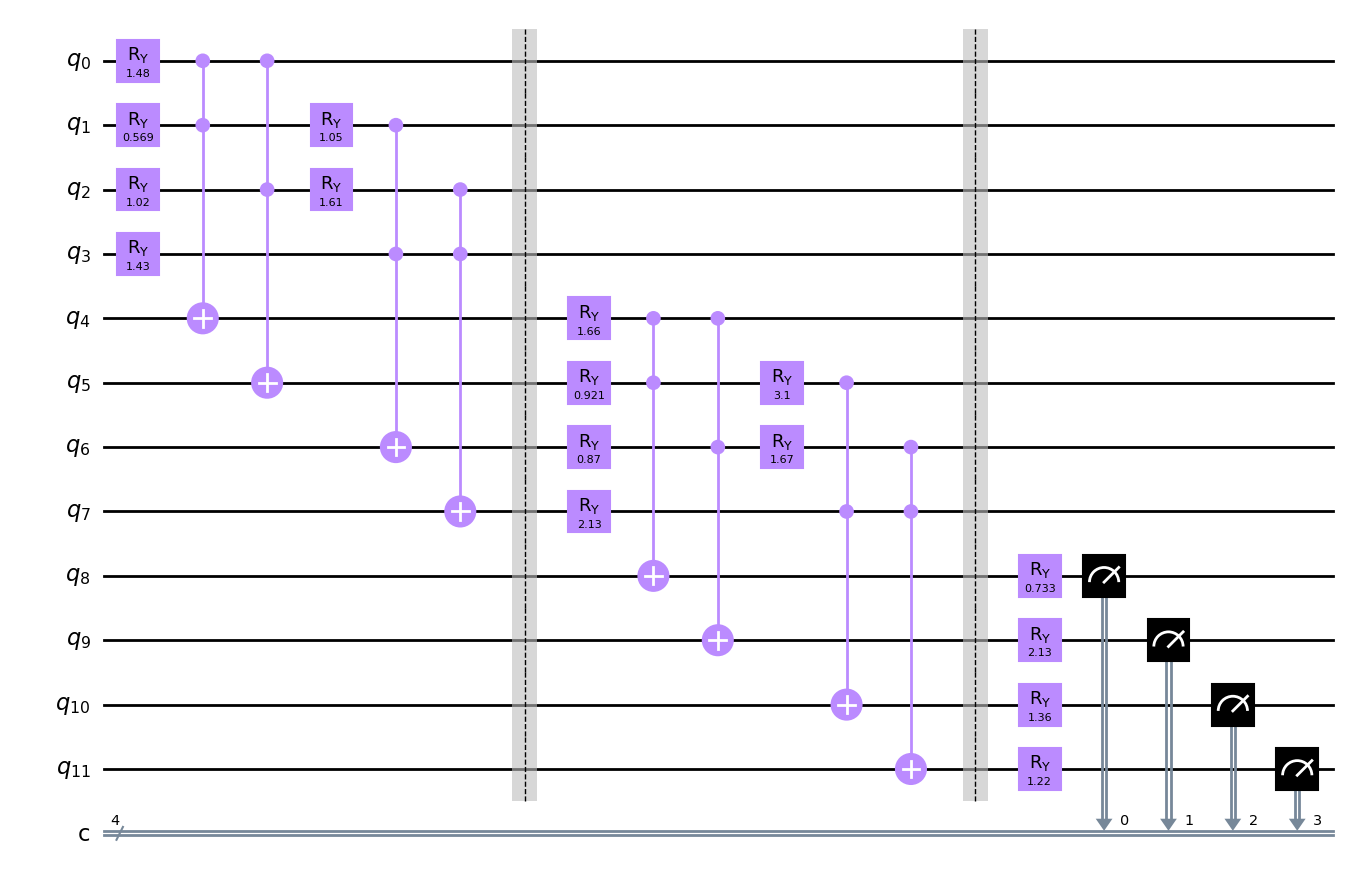

In [9]:
# A bit more advanced where we send information downward, didnt manage to make it modular so its hardcoded
class AdvancedQuantumNN:
    def __init__(self):
        self.n_qubits = 12
        self.n_params = 16
        self.params = [Parameter(f"\u03b8_{i}") for i in range(self.n_params)]
        self.qc = self.create_advanced_variational_circuit()
        self.values = [np.random.uniform(0, np.pi) for _ in self.params]

    def get_parameters(self):
        return self.params

    def get_values(self):
        return self.values

    def update_values(self, values):
        self.values = values
    
    def get_qc(self, values=None):
        if values is None:  # Use 'is None' for checking against None
            param_values = {param: value for param, value in zip(self.params, self.values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        else:
            param_values = {param: value for param, value in zip(self.params, values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        return new_qc

    def create_advanced_variational_circuit(self):
        qc = QuantumCircuit(self.n_qubits, 4)
        qc.ry(self.params[0], 0)
        qc.ry(self.params[1], 1)
        qc.ry(self.params[2], 2)
        qc.ry(self.params[3], 3)

        qc.mcx([0, 1], 4)
        qc.mcx([0, 2], 5)
        qc.ry(self.params[12], 1)
        qc.ry(self.params[13], 2)
        qc.mcx([1, 3], 6)
        qc.mcx([2, 3], 7)

        qc.barrier()
        
        qc.ry(self.params[4], 4)
        qc.ry(self.params[5], 5)
        qc.ry(self.params[6], 6)
        qc.ry(self.params[7], 7)

        qc.mcx([4, 5], 8)
        qc.mcx([4, 6], 9)
        qc.ry(self.params[14], 5)
        qc.ry(self.params[15], 6)
        qc.mcx([5, 7], 10)
        qc.mcx([6, 7], 11)

        qc.barrier()
        qc.ry(self.params[8], 8)
        qc.ry(self.params[9], 9)
        qc.ry(self.params[10], 10)
        qc.ry(self.params[11], 11)

        qc.measure(range(self.n_qubits - 4, self.n_qubits), range(4))
        return qc

advanced_qnn = AdvancedQuantumNN()
qc = advanced_qnn.get_qc()
qc.draw(output="mpl")


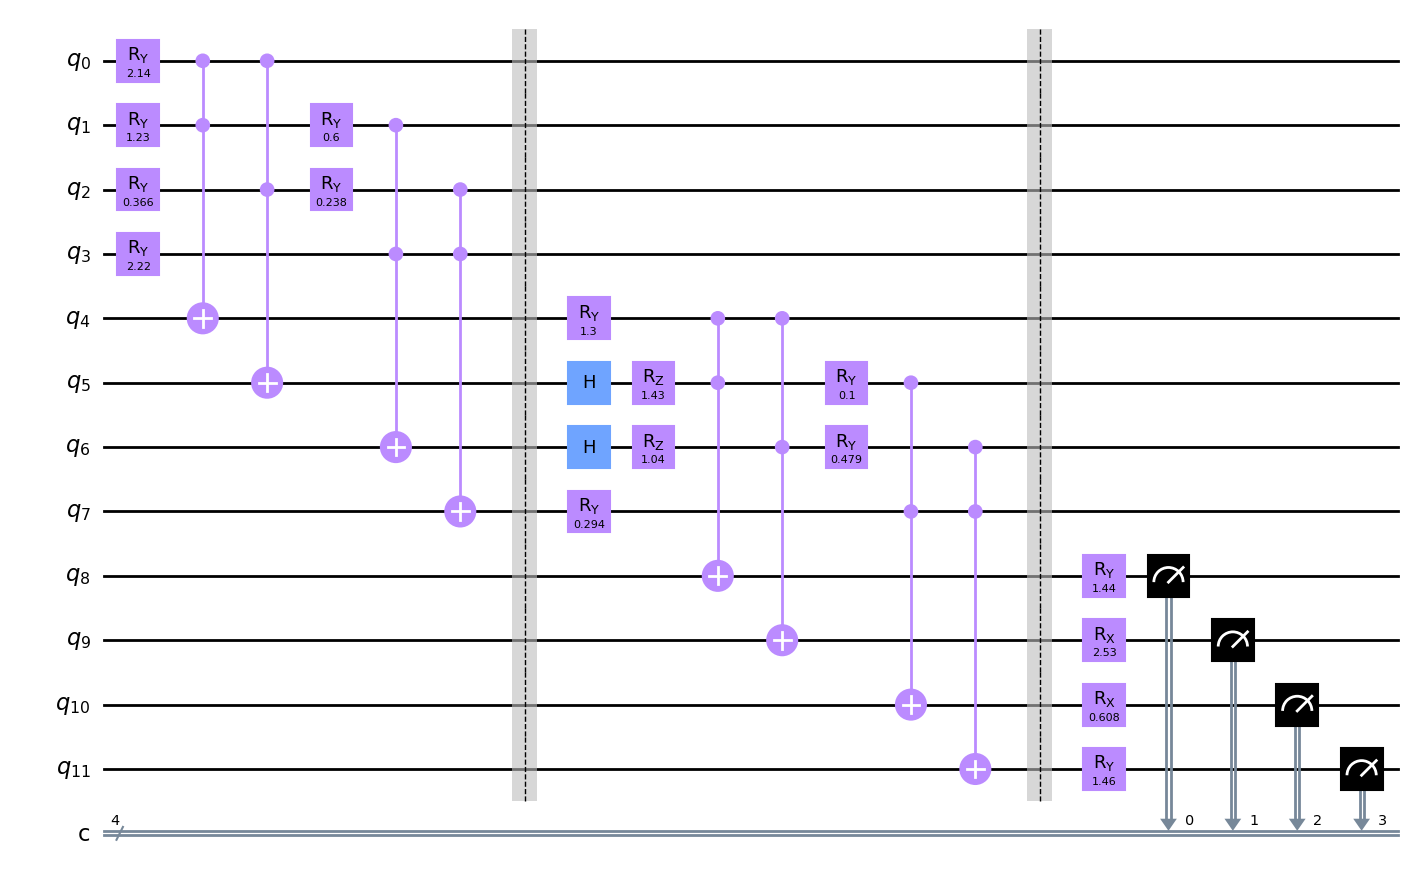

In [10]:
## Added some hademard and z gates to see difference
class AdvancedQuantumNN2:
    def __init__(self):
        self.n_qubits = 12
        self.n_params = 16
        self.params = [Parameter(f"\u03b8_{i}") for i in range(self.n_params)]
        self.qc = self.create_advanced_variational_circuit()
        self.values = [np.random.uniform(0, np.pi) for _ in self.params]

    def get_parameters(self):
        return self.params

    def get_values(self):
        return self.values

    def update_values(self, values):
        self.values = values
    
    def get_qc(self, values=None):
        if values is None:  # Use 'is None' for checking against None
            param_values = {param: value for param, value in zip(self.params, self.values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        else:
            param_values = {param: value for param, value in zip(self.params, values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        return new_qc

    def create_advanced_variational_circuit(self):
        qc = QuantumCircuit(self.n_qubits, 4)
        qc.ry(self.params[0], 0)
        qc.ry(self.params[1], 1)
        qc.ry(self.params[2], 2)
        qc.ry(self.params[3], 3)

        qc.mcx([0, 1], 4)
        qc.mcx([0, 2], 5)
        qc.ry(self.params[12], 1)
        qc.ry(self.params[13], 2)
        qc.mcx([1, 3], 6)
        qc.mcx([2, 3], 7)

        qc.barrier()
        qc.h(5)
        qc.h(6)
        qc.ry(self.params[4], 4)
        qc.rz(self.params[5], 5)
        qc.rz(self.params[6], 6)
        qc.ry(self.params[7], 7)

        qc.mcx([4, 5], 8)
        qc.mcx([4, 6], 9)
        qc.ry(self.params[14], 5)
        qc.ry(self.params[15], 6)
        qc.mcx([5, 7], 10)
        qc.mcx([6, 7], 11)

        qc.barrier()
        qc.ry(self.params[8], 8)
        qc.rx(self.params[9], 9)
        qc.rx(self.params[10], 10)
        qc.ry(self.params[11], 11)

        qc.measure(range(self.n_qubits - 4, self.n_qubits), range(4))
        return qc

advanced_qnn = AdvancedQuantumNN2()
qc = advanced_qnn.get_qc()
qc.draw(output="mpl")


In [11]:
def run_qc(qc, shots=1000, label_mapping = {
        '0000': '0', '0001': '1', '0010': '2', '0011': '0',
        '0100': '1', '0101': '2', '0110': '0', '0111': '1',
        '1000': '2', '1001': '0', '1010': '1', '1011': '2',
        '1100': '0', '1101': '1', '1110': '2', '1111': '0'
    },seed=random_seed):
    simulator = AerSimulator()
    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots,seed_simulator=seed).result()
    counts = result.get_counts()
    
    label_counts = {'0': 0, '1': 0, '2': 0}
    for outcome, count in counts.items():
        label = label_mapping[outcome]
        label_counts[label] += count
    total_counts = sum(label_counts.values())
    label_probabilities = {label: count / total_counts for label, count in label_counts.items()}
    return label_probabilities

In [12]:
def calculate_loss(predicted_probs, actual):
    n = len(predicted_probs)
    actual_list = [1 if i == actual else 0 for i in range(n)]    
    predicted_probs_list = []
    for i in range(n):
        predicted_probs_list.append(predicted_probs[str(i)])
    loss = log_loss([actual_list], [predicted_probs_list])
    return loss


def calc_gradient(neg_loss, pos_loss, epsilon):
    gradient = (pos_loss - neg_loss) / (2 * epsilon)
    return gradient


def evaluate_loss(enc_qc, qnn, parameters, shift, index, actual):
    shifted_parameters = parameters[:]
    shifted_parameters[index] += shift
    
    shifted_qc = qnn.get_qc(values=shifted_parameters)
    shifted_qc = enc_qc.compose(shifted_qc)
    
    shifted_probs = run_qc(shifted_qc)
    shifted_loss = calculate_loss(shifted_probs, actual)

    return shifted_loss

def gradient_descent(enc_qc, qnn, actual, epsilon=0.1, lr=0.1):
    gradients = []
    original_parameters =  np.array(qnn.get_values())
    
    for i in range(len(original_parameters)):
        lower_loss = evaluate_loss(enc_qc, qnn, original_parameters, -epsilon, i, actual)
        upper_loss = evaluate_loss(enc_qc, qnn, original_parameters, epsilon, i, actual)
        
        gradient = calc_gradient(lower_loss, upper_loss, epsilon)
        gradients.append(gradient)

    gradients =  np.array(gradients)
    new_values = original_parameters - (lr * gradients)
    qnn.update_values(new_values)

    return new_values



In [13]:
## Loss function using cross-entropy

def calc_accuracy_loss(qnn, X, y):
    correct_predictions = 0
    loss = 0
    n = len(X)
    for i in range(n):
        features = X[i]
        actual = y[i]
        enc_qc = create_encoding_circuit(features, n_qubits=qnn.n_qubits)

        qc = enc_qc.compose(qnn.get_qc())
        probs = run_qc(qc)

        loss += calculate_loss(probs, actual)

        predicted = max(probs, key=probs.get)
        if int(predicted) == actual:
            correct_predictions += 1

    loss = loss / len(X)
    accuracy = correct_predictions / len(X)
    return accuracy, loss
    

In [14]:
def plot_learning_curves(training_losses, validation_losses, epochs):
    """Plot the training and validation learning curves."""
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), training_losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), validation_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


# For Training the models
def train(qnn, X_train, y_train, X_val, y_val, lr=0.1, epsilon=0.1, epochs=20, batch_size=8, patience=3):
    training_losses = []
    validation_losses = []

    best_parameters = []
    best_validation_loss = float('inf')
    best_validation_accuracy = 0
    patience_counter = 0


    for epoch in range(epochs):
        print(f"Epoch {epoch + 1 } of {epochs}")
        batch_indices = np.random.choice(len(X_train), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]

        cur_parameters = []
        for i in range(len(X_batch)):
            features = X_batch[i]
            actual = y_batch[i]
            enc_qc = create_encoding_circuit(features, n_qubits=qnn.n_qubits)

            cur_parameters = gradient_descent(enc_qc, qnn, actual, epsilon=epsilon, lr=lr)
        
        cur_validation_accuracy, cur_validation_loss = calc_accuracy_loss(qnn, X_val, y_val)
        training_accuracy, cur_training_loss = calc_accuracy_loss(qnn, X_train, y_train)

        print(f"Val accuracy: {round(cur_validation_accuracy, 2)}, training accuracy: {round(training_accuracy, 2)}")
        validation_losses.append(cur_validation_loss)
        training_losses.append(cur_training_loss)
        
        if cur_validation_loss < best_validation_loss:
            best_validation_loss = cur_validation_loss
            best_validation_accuracy = cur_validation_accuracy
            best_parameters = cur_parameters
            patience_counter = 0
        else:
            patience += 1
            if patience_counter >= patience:
                print("Validation loss increased, stopping early due to patience limit")
                break

    plot_learning_curves(training_losses, validation_losses, epochs)
    qnn.update_values(best_parameters)

    return best_parameters,best_validation_accuracy,best_validation_loss
    
        
        

## Testing different models

In [15]:
model_performances = {}

Epoch 1 of 20
Val accuracy: 0.7, training accuracy: 0.64
Epoch 2 of 20
Val accuracy: 0.67, training accuracy: 0.64
Epoch 3 of 20
Val accuracy: 0.67, training accuracy: 0.64
Epoch 4 of 20
Val accuracy: 0.67, training accuracy: 0.64
Epoch 5 of 20
Val accuracy: 0.73, training accuracy: 0.72
Epoch 6 of 20
Val accuracy: 0.67, training accuracy: 0.69
Epoch 7 of 20
Val accuracy: 0.7, training accuracy: 0.73
Epoch 8 of 20
Val accuracy: 0.67, training accuracy: 0.67
Epoch 9 of 20
Val accuracy: 0.77, training accuracy: 0.76
Epoch 10 of 20
Val accuracy: 0.73, training accuracy: 0.77
Epoch 11 of 20
Val accuracy: 0.67, training accuracy: 0.63
Epoch 12 of 20
Val accuracy: 0.67, training accuracy: 0.7
Epoch 13 of 20
Val accuracy: 0.7, training accuracy: 0.7
Epoch 14 of 20
Val accuracy: 0.8, training accuracy: 0.82
Epoch 15 of 20
Val accuracy: 0.7, training accuracy: 0.63
Epoch 16 of 20
Val accuracy: 0.7, training accuracy: 0.63
Epoch 17 of 20
Val accuracy: 0.73, training accuracy: 0.79
Epoch 18 of 20

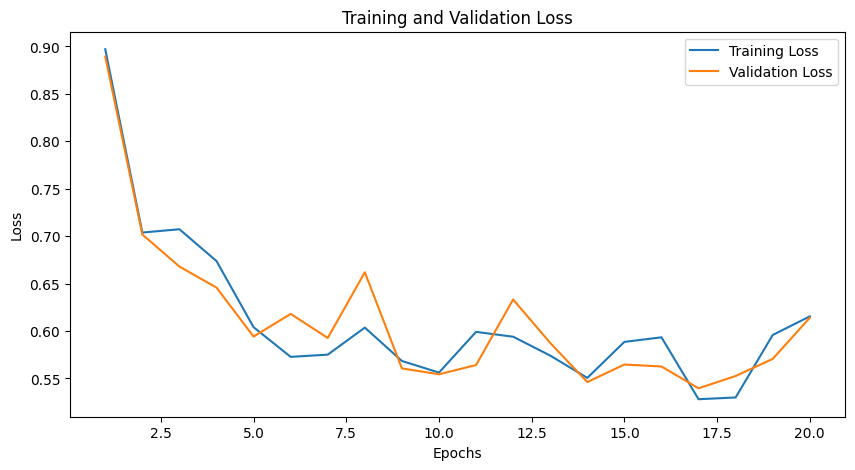

In [16]:
qnn1 = QuantumNN(4,4)
parameters,validation_accuracy, validation_loss = train(qnn1, X_train, y_train, X_val, y_val, lr=0.5, epsilon=0.1)

model_performances[qnn1] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.7, training accuracy: 0.7
Epoch 2 of 20
Val accuracy: 0.77, training accuracy: 0.78
Epoch 3 of 20
Val accuracy: 0.67, training accuracy: 0.7
Epoch 4 of 20
Val accuracy: 0.83, training accuracy: 0.88
Epoch 5 of 20
Val accuracy: 0.7, training accuracy: 0.76
Epoch 6 of 20
Val accuracy: 0.67, training accuracy: 0.66
Epoch 7 of 20
Val accuracy: 0.73, training accuracy: 0.73
Epoch 8 of 20
Val accuracy: 0.9, training accuracy: 0.88
Epoch 9 of 20
Val accuracy: 0.87, training accuracy: 0.88
Epoch 10 of 20
Val accuracy: 0.73, training accuracy: 0.73
Epoch 11 of 20
Val accuracy: 0.77, training accuracy: 0.86
Epoch 12 of 20
Val accuracy: 0.87, training accuracy: 0.94
Epoch 13 of 20
Val accuracy: 0.73, training accuracy: 0.72
Epoch 14 of 20
Val accuracy: 0.67, training accuracy: 0.68
Epoch 15 of 20
Val accuracy: 0.9, training accuracy: 0.89
Epoch 16 of 20
Val accuracy: 0.73, training accuracy: 0.74
Epoch 17 of 20
Val accuracy: 0.87, training accuracy: 0.98
Epoch 18 of 

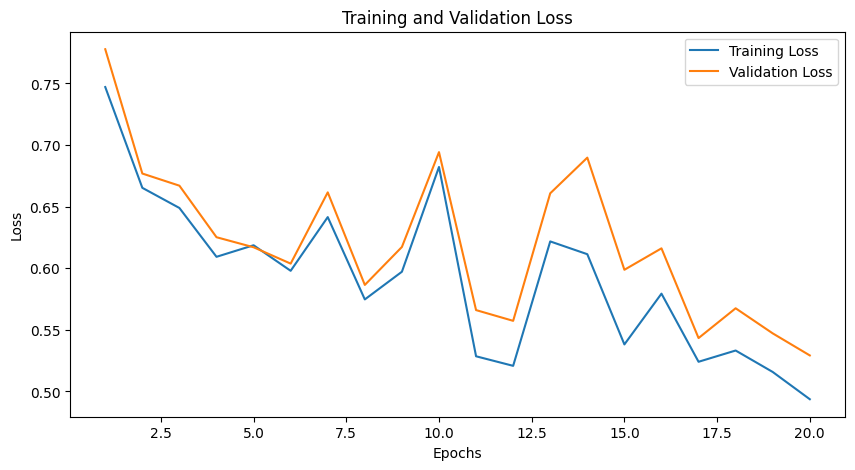

In [17]:
qnn2 = QuantumNN(4,4)
parameters,validation_accuracy, validation_loss = train(qnn2, X_train, y_train, X_val, y_val, lr=1, epsilon=0.1)
model_performances[qnn2] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.63, training accuracy: 0.61
Epoch 2 of 20
Val accuracy: 0.8, training accuracy: 0.78
Epoch 3 of 20
Val accuracy: 0.77, training accuracy: 0.74
Epoch 4 of 20
Val accuracy: 0.7, training accuracy: 0.72
Epoch 5 of 20
Val accuracy: 0.63, training accuracy: 0.7
Epoch 6 of 20
Val accuracy: 0.67, training accuracy: 0.72
Epoch 7 of 20
Val accuracy: 0.77, training accuracy: 0.77
Epoch 8 of 20
Val accuracy: 0.67, training accuracy: 0.67
Epoch 9 of 20
Val accuracy: 0.9, training accuracy: 0.87
Epoch 10 of 20
Val accuracy: 0.8, training accuracy: 0.78
Epoch 11 of 20
Val accuracy: 0.93, training accuracy: 0.91
Epoch 12 of 20
Val accuracy: 0.67, training accuracy: 0.72
Epoch 13 of 20
Val accuracy: 0.67, training accuracy: 0.73
Epoch 14 of 20
Val accuracy: 0.67, training accuracy: 0.71
Epoch 15 of 20
Val accuracy: 0.87, training accuracy: 0.8
Epoch 16 of 20
Val accuracy: 0.77, training accuracy: 0.78
Epoch 17 of 20
Val accuracy: 0.83, training accuracy: 0.79
Epoch 18 of 

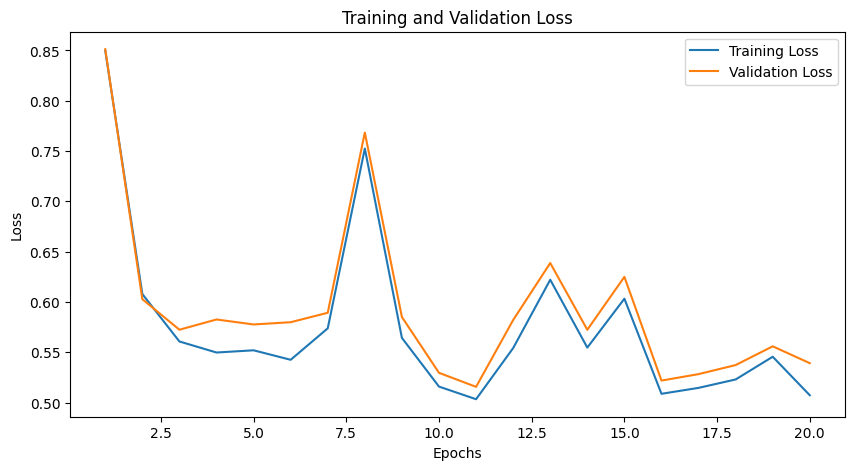

In [19]:
qnn3 = QuantumNN(3,4)
parameters,validation_accuracy, validation_loss = train(qnn3, X_train, y_train, X_val, y_val, lr=1.5, epsilon=0.1)
model_performances[qnn3] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.37, training accuracy: 0.26
Epoch 2 of 20
Val accuracy: 0.5, training accuracy: 0.38
Epoch 3 of 20
Val accuracy: 0.5, training accuracy: 0.51
Epoch 4 of 20
Val accuracy: 0.63, training accuracy: 0.59
Epoch 5 of 20
Val accuracy: 0.6, training accuracy: 0.67
Epoch 6 of 20
Val accuracy: 0.77, training accuracy: 0.81
Epoch 7 of 20
Val accuracy: 0.77, training accuracy: 0.86
Epoch 8 of 20
Val accuracy: 0.8, training accuracy: 0.74
Epoch 9 of 20
Val accuracy: 0.77, training accuracy: 0.77
Epoch 10 of 20
Val accuracy: 0.8, training accuracy: 0.77
Epoch 11 of 20
Val accuracy: 0.9, training accuracy: 0.82
Epoch 12 of 20
Val accuracy: 0.97, training accuracy: 0.88
Epoch 13 of 20
Val accuracy: 0.93, training accuracy: 0.88
Epoch 14 of 20
Val accuracy: 0.9, training accuracy: 0.88
Epoch 15 of 20
Val accuracy: 0.9, training accuracy: 0.89
Epoch 16 of 20
Val accuracy: 0.9, training accuracy: 0.89
Epoch 17 of 20
Val accuracy: 0.9, training accuracy: 0.91
Epoch 18 of 20
V

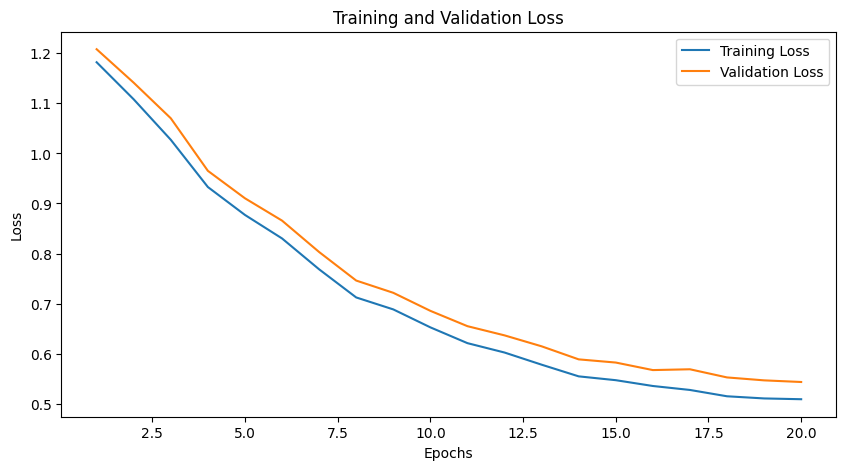

In [20]:
qnn4 = QuantumNN(6,4)
parameters,validation_accuracy, validation_loss = train(qnn4, X_train, y_train, X_val, y_val, lr=0.1, epsilon=0.1)
model_performances[qnn4] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.17, training accuracy: 0.11
Epoch 2 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 3 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 4 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 5 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 6 of 20
Val accuracy: 0.27, training accuracy: 0.32
Epoch 7 of 20
Val accuracy: 0.27, training accuracy: 0.26
Epoch 8 of 20
Val accuracy: 0.33, training accuracy: 0.38
Epoch 9 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 10 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 11 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 12 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 13 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 14 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 15 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 16 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 17 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 18 of 20
Val 

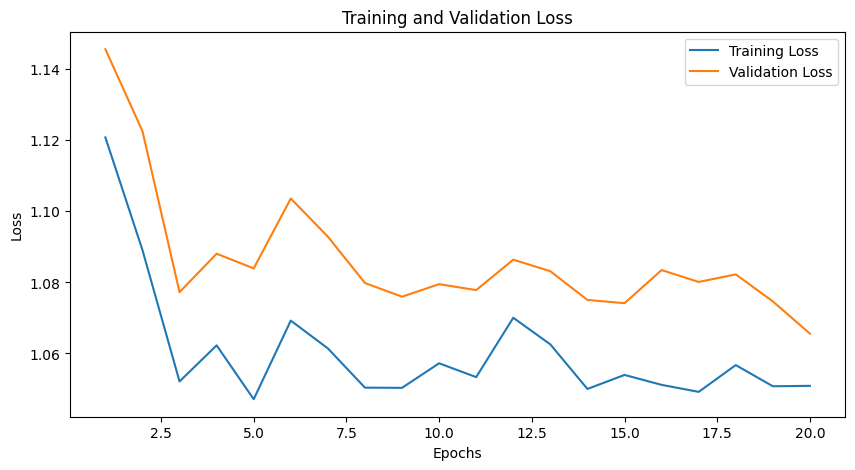

In [21]:
adv_qnn1 = AdvancedQuantumNN()
parameters,validation_accuracy, validation_loss = train(adv_qnn1, X_train, y_train, X_val, y_val, lr=0.3, epsilon=0.1)
model_performances[adv_qnn1] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 2 of 20
Val accuracy: 0.33, training accuracy: 0.38
Epoch 3 of 20
Val accuracy: 0.4, training accuracy: 0.43
Epoch 4 of 20
Val accuracy: 0.5, training accuracy: 0.62
Epoch 5 of 20
Val accuracy: 0.5, training accuracy: 0.57
Epoch 6 of 20
Val accuracy: 0.57, training accuracy: 0.64
Epoch 7 of 20
Val accuracy: 0.6, training accuracy: 0.71
Epoch 8 of 20
Val accuracy: 0.5, training accuracy: 0.47
Epoch 9 of 20
Val accuracy: 0.53, training accuracy: 0.64
Epoch 10 of 20
Val accuracy: 0.5, training accuracy: 0.53
Epoch 11 of 20
Val accuracy: 0.53, training accuracy: 0.53
Epoch 12 of 20
Val accuracy: 0.47, training accuracy: 0.47
Epoch 13 of 20
Val accuracy: 0.47, training accuracy: 0.57
Epoch 14 of 20
Val accuracy: 0.6, training accuracy: 0.58
Epoch 15 of 20
Val accuracy: 0.57, training accuracy: 0.61
Epoch 16 of 20
Val accuracy: 0.5, training accuracy: 0.59
Epoch 17 of 20
Val accuracy: 0.53, training accuracy: 0.58
Epoch 18 of 20


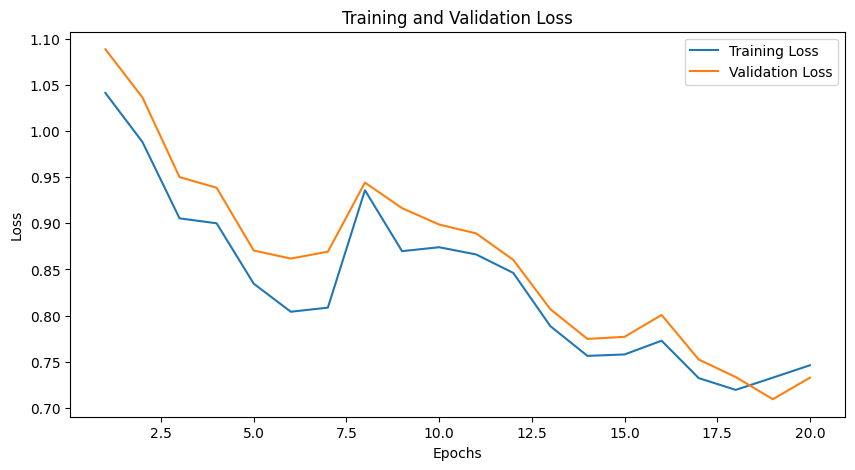

In [22]:
adv_qnn2 = AdvancedQuantumNN()
parameters,validation_accuracy, validation_loss = train(adv_qnn2, X_train, y_train, X_val, y_val, lr=1, epsilon=0.2)
model_performances[adv_qnn2] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 2 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 3 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 4 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 5 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 6 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 7 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 8 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 9 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 10 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 11 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 12 of 20
Val accuracy: 0.3, training accuracy: 0.37
Epoch 13 of 20
Val accuracy: 0.2, training accuracy: 0.19
Epoch 14 of 20
Val accuracy: 0.2, training accuracy: 0.22
Epoch 15 of 20
Val accuracy: 0.3, training accuracy: 0.32
Epoch 16 of 20
Val accuracy: 0.3, training accuracy: 0.36
Epoch 17 of 20
Val accuracy: 0.33, training accuracy: 0.42
Epoch 18 of 20
Val acc

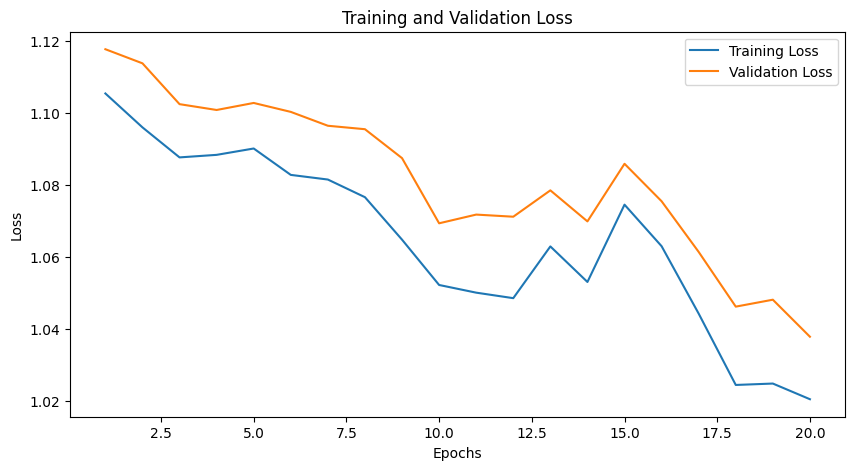

In [23]:
adv_qnn3 = AdvancedQuantumNN2()
parameters,validation_accuracy, validation_loss = train(adv_qnn3, X_train, y_train, X_val, y_val, lr=0.3, epsilon=0.2)
model_performances[adv_qnn3] = validation_accuracy

Epoch 1 of 20
Val accuracy: 0.33, training accuracy: 0.33
Epoch 2 of 20
Val accuracy: 0.33, training accuracy: 0.33
Epoch 3 of 20
Val accuracy: 0.33, training accuracy: 0.33
Epoch 4 of 20
Val accuracy: 0.33, training accuracy: 0.33
Epoch 5 of 20
Val accuracy: 0.63, training accuracy: 0.53
Epoch 6 of 20
Val accuracy: 0.57, training accuracy: 0.57
Epoch 7 of 20
Val accuracy: 0.53, training accuracy: 0.52
Epoch 8 of 20
Val accuracy: 0.43, training accuracy: 0.43
Epoch 9 of 20
Val accuracy: 0.43, training accuracy: 0.41
Epoch 10 of 20
Val accuracy: 0.43, training accuracy: 0.41
Epoch 11 of 20
Val accuracy: 0.43, training accuracy: 0.41
Epoch 12 of 20
Val accuracy: 0.43, training accuracy: 0.41
Epoch 13 of 20
Val accuracy: 0.47, training accuracy: 0.46
Epoch 14 of 20
Val accuracy: 0.73, training accuracy: 0.8
Epoch 15 of 20
Val accuracy: 0.77, training accuracy: 0.8
Epoch 16 of 20
Val accuracy: 0.67, training accuracy: 0.67
Epoch 17 of 20
Val accuracy: 0.67, training accuracy: 0.67
Epoch 18

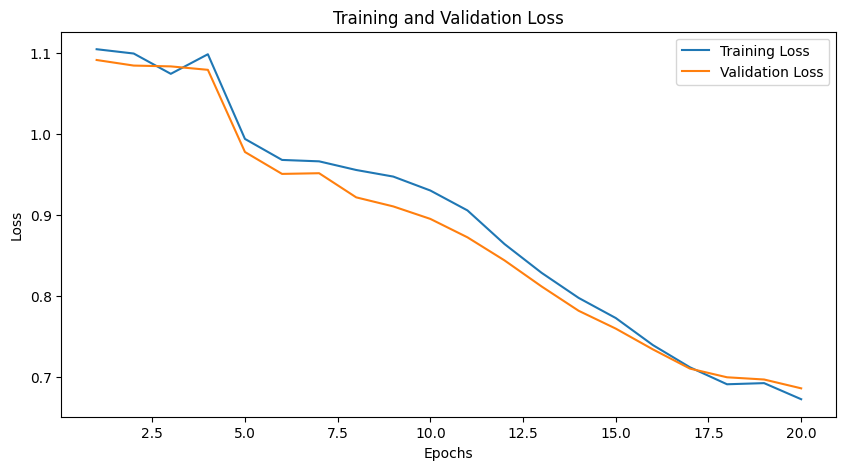

In [24]:
adv_qnn4 = AdvancedQuantumNN2()
parameters,validation_accuracy, validation_loss = train(adv_qnn4, X_train, y_train, X_val, y_val, lr=1, epsilon=0.2)
model_performances[adv_qnn4] = validation_accuracy

## Evaluate best model


C:\Users\halfd\inf2\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


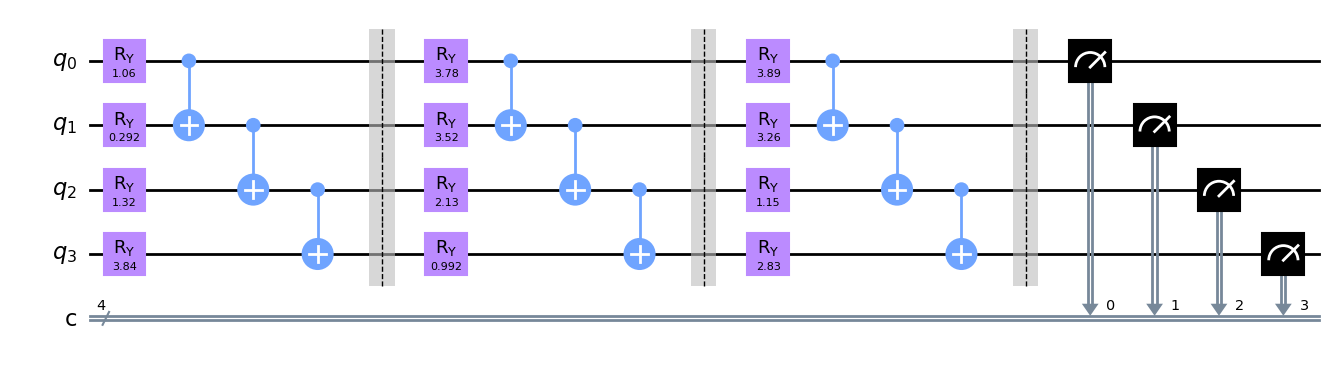

In [25]:
best_model = max(model_performances, key=model_performances.get)

best_model.get_qc().draw(output="mpl")


In [26]:
calc_accuracy_loss(best_model, X_test, y_test)

(0.9333333333333333, 0.512363819106688)